# **Section 2: Splitting the data**
In this section, I will split the data into training, validation and test sets. 

To ensure that the model learns to predict **resistance** and not **lineage**, I will define the test set to contain strains with **Sequence Types** not present in the training or validation sets. This allow testing the model on lineages that aren't present in the training or validation sets, and provides a more accurate estimation of the performance of the model on unknown samples. 

The information about the sequence type is found in the genome_metadata.csv file. I will thus import the file and clean it before defining the test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_palette("pastel")

## **1. Loading and cleaning the data**

### **1.1 Load feature matrix and resistance profiles**

In [2]:
# Load features and labels
cnv_data = pd.read_csv("Data/cnvs_cleaned.csv", index_col=0)
profiles = pd.read_csv("Data/SXT_cleaned.csv", index_col=0)

print(f"Data shape: {cnv_data.shape}")
print(f"Label shape: {profiles.shape}")
print(f"Categories: {np.unique(profiles)}")

Data shape: (227, 11719)
Label shape: (227, 1)
Categories: [0 1]


### **1.2 Load metadata**

In [3]:
metadata = pd.read_csv('../genome_metadata_cleaned.csv', index_col=0)
print(f"Metadata shape: {metadata.shape}")
print(f"Metadata columns: {metadata.columns}")

Metadata shape: (227, 6)
Metadata columns: Index(['genome_name', 'source', 'species', 'resistance_profile', 'ST',
       'location'],
      dtype='str')


### **1.3 Metadata cleaning**
Let's now set the index as the sra_accession and clean the metadata. Some of the strains do not have an ST or a location. Let's fill all empty values with "unknown"

In [4]:
metadata = metadata.fillna("unknown")

## **2. Splitting the data**
I will now split the data into the training, validation and test sets.

### **2.1 Choosing STs for the test set**
Let's first have a look at the distribution of the difference Sequence Types (STs) in our data to see which ones we should set aside for the test set. 

In [5]:
# Some statistics
print(f"Unique STs: {metadata['ST'].nunique()}")
print(f"\nST distribution:")
print(metadata['ST'].value_counts().sort_values(ascending=False).head(10))

Unique STs: 59

ST distribution:
ST
70          23
Novel ST    20
512         15
306         14
10          13
unknown     10
54           8
167          7
34           7
219          6
Name: count, dtype: int64


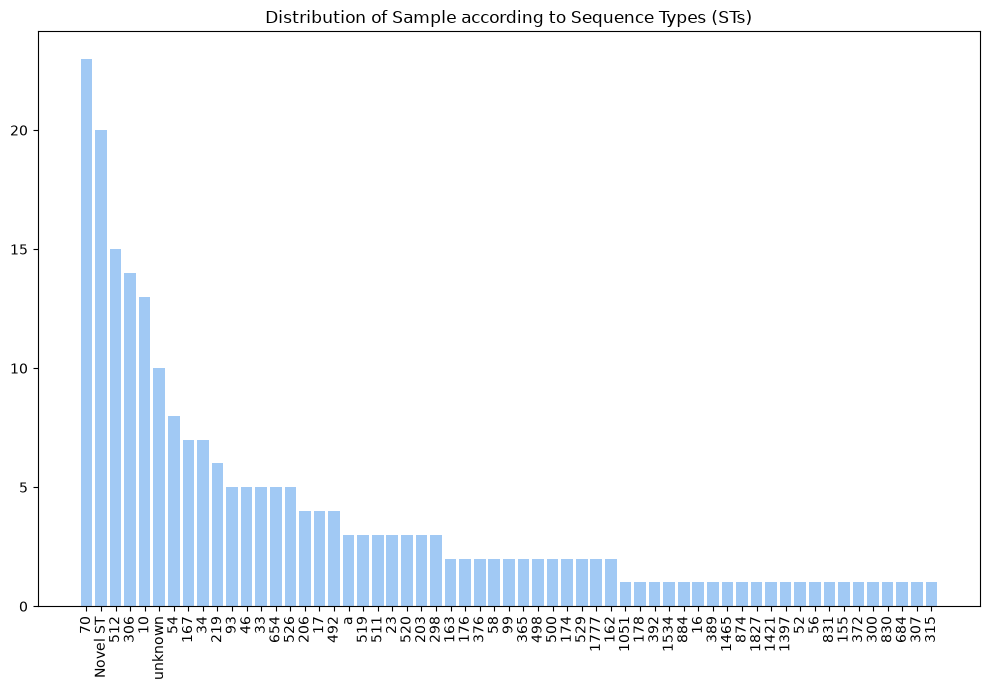

In [6]:
fig, axes = plt.subplots(figsize=(10, 7))

axes.bar(x=metadata["ST"].value_counts().sort_values(ascending=False).index,
        height=metadata["ST"].value_counts().sort_values(ascending=False).values)

plt.xticks(rotation=90)
plt.title("Distribution of Sample according to Sequence Types (STs)")
plt.tight_layout()
plt.show()

We see that most sequence types contain very little samples (a lot only contain one or two samples). For the test set, I will set aside sequence types **70**,**306**, **54**, and **46**.

This should provide us with a test set that contains around 50 samples and that isn't too diverse. More importantly, the model is not trained with strains from the lineages in the test set, and we can thus more accurately assess how well the model will perform on unseen data with this test set. 

### **2.2 Splitting the test set**

In [7]:
# Identify test samples
test_mask = metadata["ST"].isin(["46", "54", "70", "306"])
print(f"There are {test_mask.sum()} strains with Sequence Types 46, 54, 70 and 306")

# Create the test set
cnv_test = cnv_data[test_mask]
profiles_test = profiles[test_mask]

print("\nTest data shape:")
print(cnv_test.shape)
print(profiles_test.shape)

There are 50 strains with Sequence Types 46, 54, 70 and 306

Test data shape:
(50, 11719)
(50, 1)


### **2.3 Splitting the validation and training sets**
Let's now assign the leftover samples to a training set.

In [8]:
#create the "training and validation" set with the leftover values
cnv_train = cnv_data[~test_mask]
profiles_train = profiles[~test_mask]

print("\nTraining and validation data shape:")
print(cnv_train.shape)
print(profiles_train.shape)


Training and validation data shape:
(177, 11719)
(177, 1)


### **2.4 Saving the data**

In [9]:
cnv_test.to_csv("Data/cnv_test.csv")
cnv_train.to_csv("Data/cnv_train.csv")

profiles_test.to_csv("Data/SXT_test.csv")
profiles_train.to_csv("Data/SXT_train.csv")